# 02 — Exploratory Data Analysis

This notebook explores the clean Facebook dataset to understand patterns in post
performance. It moves from broad overview to specific variables.

**Input:** `data/clean_posts.csv` (produced by `01_clean.ipynb`)

**Sections:**
1. Setup
2. Dataset Overview
   - 2.1 Key metrics summary
   - 2.2 Post type breakdown
   - 2.3 Understanding Content vs Photo
   - 2.4 Top performing posts
3. Engagement Metrics
   - 3.1 Distributions
   - 3.2 Algorithmic reach vs audience engagement (quadrant plot)
   - 3.3 Metric correlations
4. Post Type Analysis
   - 4.1 Engagement by post type
   - 4.2 Views and view rates by post type
   - 4.3 Post category breakdown by type
5. Timing Analysis
   - 5.1 Hour of day
   - 5.2 Day of week
   - 5.3 Combined: hour, day, and post type
6. Text Length Analysis
7. OLS Regression: What predicts performance?
8. Key Findings

## 1. Setup

Load libraries and the clean dataset. All analysis in this notebook reads from
`clean_posts.csv` — never from the raw Facebook export.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

sns.set_theme(style="whitegrid")

WEEKDAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

df = pd.read_csv(Path("../data/clean_posts.csv"))

# Restore datetime type (CSV doesn't preserve it)
df["publish_time"] = pd.to_datetime(df["publish_time"])

print(f"Loaded {len(df)} posts — {df['date'].min()} to {df['date'].max()}")

Loaded 97 posts — 2025-06-04 to 2026-03-19


## 2. Dataset Overview

Before looking at individual variables, we start with the big picture:
how many posts, what types, and which ones stood out the most.

### 2.1 Key Metrics Summary

A statistical summary of all engagement metrics — gives a sense of scale,
typical values, and how much variation exists.

In [28]:
metric_cols = ["reactions", "comments", "shares", "saves",
               "impressions", "interactions", "views", "viewers",
               "engagement_rate", "repeat_view_rate", "view_through_rate"]

df[metric_cols].describe().round(2)

,reactions,comments,shares,saves,impressions,interactions,views,viewers,engagement_rate,repeat_view_rate,view_through_rate
count,97.00,97.00,97.00,97.00,97.00,97.00,97.00,92.00,97.00,92.00,92.00
mean,46.70,16.90,0.76,0.12,1176.41,60.21,1836.75,1013.14,0.07,1.91,0.83
std,26.89,13.34,1.08,0.48,1528.16,35.64,2120.61,1431.92,0.04,0.26,0.05
min,4.00,0.00,0.00,0.00,185.00,4.00,263.00,160.00,0.01,1.26,0.69
25%,28.00,8.00,0.00,0.00,520.00,35.00,762.00,437.50,0.05,1.74,0.80
50%,45.00,14.00,0.00,0.00,871.00,56.00,1460.00,691.00,0.07,1.90,0.84
75%,62.00,22.00,1.00,0.00,1220.00,77.00,1866.00,958.00,0.08,2.04,0.87
max,131.00,81.00,6.00,3.00,12503.00,204.00,16999.00,11457.00,0.32,2.74,0.95


### 2.2 Post Type Breakdown

How are posts distributed across types? This matters because different post types
have different reach mechanics on Facebook — photos get algorithmic distribution,
content (text-only) posts generally don't.

Post type distribution:
           count  percent
post_type                
Photo         75     77.3
Content       15     15.5
Reel           7      7.2


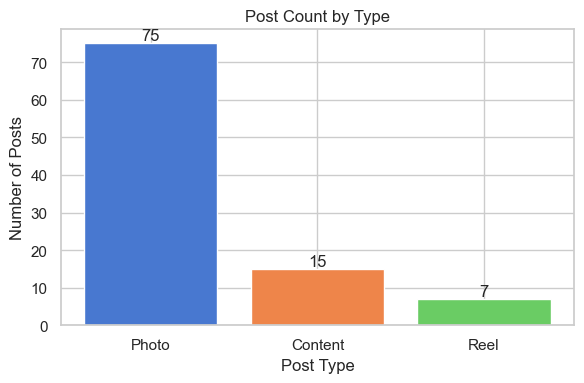

In [29]:
type_counts = df["post_type"].value_counts()
type_pct    = (type_counts / len(df) * 100).round(1)

summary = pd.DataFrame({"count": type_counts, "percent": type_pct})
print("Post type distribution:")
print(summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(type_counts.index, type_counts.values,
       color=sns.color_palette("muted", len(type_counts)))
ax.bar_label(ax.containers[0], fmt="%d")
ax.set_xlabel("Post Type")
ax.set_ylabel("Number of Posts")
ax.set_title("Post Count by Type")
plt.tight_layout()
plt.show()

### 2.3 Understanding Content vs Photo

Facebook's labels aren't always intuitive. This cell shows sample posts from each
type so we can confirm what 'Content' and 'Photo' actually mean in this dataset
and ensure we're interpreting the types correctly.

In [30]:
for post_type in ["Content", "Photo", "Reel"]:
    subset = df[df["post_type"] == post_type][["title", "date", "time"]].head(6)
    print("=" * 80)
    print(f"  {post_type.upper()} posts ({len(df[df['post_type'] == post_type])} total)")
    print("=" * 80)
    display(subset.reset_index(drop=True))
    print()

  CONTENT posts (15 total)


,title,date,time
0,מפגש עם ספר הוא לפעמים גם מפגש בין שני אנשים ש...,2026-03-12,08:07:00
1,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקי...",2026-03-01,18:58:00
2,ענת כתבה על #בין_המסדרונות מילים שנגעו בי בדיו...,2026-02-24,07:56:00
3,"אמנם אני ברזידנסי, מנסה לכתוב את האח הקטן,\nאב...",2026-02-10,07:45:00
4,לפעמים הקוראים מצליחים לסכם את הספר שלך יותר ט...,2026-01-25,08:47:00
5,התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshe...,2026-01-15,19:36:00



  PHOTO posts (75 total)


,title,date,time
0,חופשה עם ילדים זאת מעין חצי חופשה. \n\nלא מקבל...,2025-08-14,08:01:00
1,מלחמה וסטרס עושות משהו מעניין לזמן.\n\nהן מותח...,2026-03-19,07:45:00
2,מה אנחנו באמת רוצים כשאנחנו חושקים במישהו?\n\n...,2026-03-16,07:30:00
3,"בימים מטושטשים ולא ברורים כאלה,\nאני אוהבת בעי...",2026-03-13,16:19:00
4,"יש מקומות שנשארים חרוטים בגופינו.\n\nמסדרונות,...",2026-03-10,07:45:00
5,הדבר שהכי מייצג אישה עבורי הוא שינויים. \n\nשי...,2026-03-08,19:15:00



  REEL posts (7 total)


,title,date,time
0,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנס...",2026-03-04,19:49:00
1,״קודם כל אני רוסייה. \nלא אמרתי לעצמי שאני טוב...,2026-02-15,19:41:00
2,רזידנסי כתיבה בירושלים.\n\nאנשים טובים ✔️\nסופ...,2026-02-09,18:59:00
3,קצת מאתמול. הסיפור המלא מחר…\n \n#בין_המסדרונו...,2026-01-10,20:01:00
4,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסד...,2025-12-17,07:45:00
5,לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל בי...,2025-12-10,08:43:00


### 2.4 Top Performing Posts

The highest-performing posts are worth examining individually — they often reveal
patterns that aggregate statistics miss. We look at top posts by views
and by engagement rate separately, since these capture different kinds of success.

In [31]:
# Helper: truncate title for display
def short_title(t, n=60):
    t = str(t).strip()
    return "(no title — cover photo)" if t in ("", "nan") else (t[:n] + "…" if len(t) > n else t)

display_cols = ["title_display", "post_type", "post_category", "date",
                "views", "impressions", "engagement_rate"]

# Top 10 by views
top_views = df.nlargest(10, "views").copy()
top_views["title_display"] = top_views["title"].apply(short_title)
print("Top 10 posts by VIEWS:")
display(top_views[display_cols].reset_index(drop=True))

print()

# Top 10 by engagement rate (min 200 impressions to filter outliers)
top_eng = df[df["impressions"] >= 200].nlargest(10, "engagement_rate").copy()
top_eng["title_display"] = top_eng["title"].apply(short_title)
print("Top 10 posts by ENGAGEMENT RATE (min 200 impressions):")
display(top_eng[display_cols].reset_index(drop=True))

Top 10 posts by VIEWS:


,title_display,post_type,post_category,date,views,impressions,engagement_rate
0,לפעמים אני מתגעגעת להיות בהיריון.\n\nלפני בדיו...,Photo,Algorithm Pushed,2025-12-21,16999,12503.0,0.009198
1,"קצת קשה לי להאמין, אבל הנה זה קרה...\n\nהתקבלת...",Photo,Algorithm Pushed,2025-12-23,8263,5874.0,0.024515
2,מה אנחנו באמת רוצים כשאנחנו חושקים במישהו?\n\n...,Photo,Algorithm Pushed,2026-03-16,7107,5340.0,0.011610
3,זאת הייתה שנה מיוחדת עבורי. מלאה באהבה וגם בכא...,Photo,Algorithm Pushed,2025-09-23,6692,4526.0,0.021432
4,בסוף השבוע האחרון עשיתי תאונה.\n\nתמיד פחדתי מ...,Photo,Algorithm Pushed,2025-11-17,6512,4521.0,0.023004
5,"כשאת לבד מול עצמך ועוד נמצאת ברשתות החברתיות, ...",Photo,Algorithm Pushed,2026-01-27,5320,3640.0,0.037637
6,"תמיד כשאני אומרת שהייתי בפנימייה, אני רואה איך...",Photo,Viral,2025-07-23,3961,2031.0,0.078779
7,פעם פינטזתי לכתוב בשם עט...\n\nלתת ליצירה חיים...,Photo,Viral,2025-09-07,3486,1907.0,0.070792
8,#אנשי_הגם_וגם\n\nאני ליז איזקסון משל ואני לא ר...,Photo,Algorithm Pushed,2025-11-30,3336,1986.0,0.053877
9,#חשיפת_כריכה\n\nאז הנה זה קורה. הרגע שחיכיתי ל...,Photo,Viral,2025-08-21,3118,1498.0,0.136182



Top 10 posts by ENGAGEMENT RATE (min 200 impressions):


,title_display,post_type,post_category,date,views,impressions,engagement_rate
0,מה זה אומר להנות מהרגע?\nהרבה פעמים אני שומעת ...,Photo,Audience Favorite,2025-07-02,363,219.0,0.319635
1,למה שינויים כל כך מפחידים אותנו? אולי כי הם תמ...,Photo,Audience Favorite,2025-06-04,320,201.0,0.268657
2,#חשיפת_כריכה\n\nאז הנה זה קורה. הרגע שחיכיתי ל...,Photo,Viral,2025-08-21,3118,1498.0,0.136182
3,יש לי וידוי.\n\nאני ממש אוהבת ריח של ספרים.\n\...,Reel,Audience Favorite,2025-08-28,1057,807.0,0.127633
4,התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshe...,Content,Audience Favorite,2026-01-15,520,319.0,0.112853
5,מלחמה וסטרס עושות משהו מעניין לזמן.\n\nהן מותח...,Photo,Audience Favorite,2026-03-19,831,457.0,0.105033
6,לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל בי...,Reel,Audience Favorite,2025-12-10,776,587.0,0.095400
7,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסד...,Reel,Audience Favorite,2025-12-17,565,506.0,0.088933
8,כמה מרגש לקבל סקירה כזאת מעמיקה על #בין_המסדרו...,Content,Audience Favorite,2025-10-03,653,397.0,0.088161
9,"זאת הייתה שנה מיוחדת ומורכבת, השנה השלושים ושש...",Photo,Viral,2025-12-12,2103,1262.0,0.087956


## 3. Engagement Metrics

Now we look at how the engagement metrics are distributed and how they relate
to each other.

### 3.1 Distributions

Understanding the shape of each metric's distribution tells us:
- Whether the mean or median is a better summary statistic
- How many outliers exist and how extreme they are
- Whether we need to transform the data (e.g. log-scale) before modeling

Right-skewed distributions (long tail to the right) are typical for social media
metrics — most posts perform modestly, a few perform extremely well.

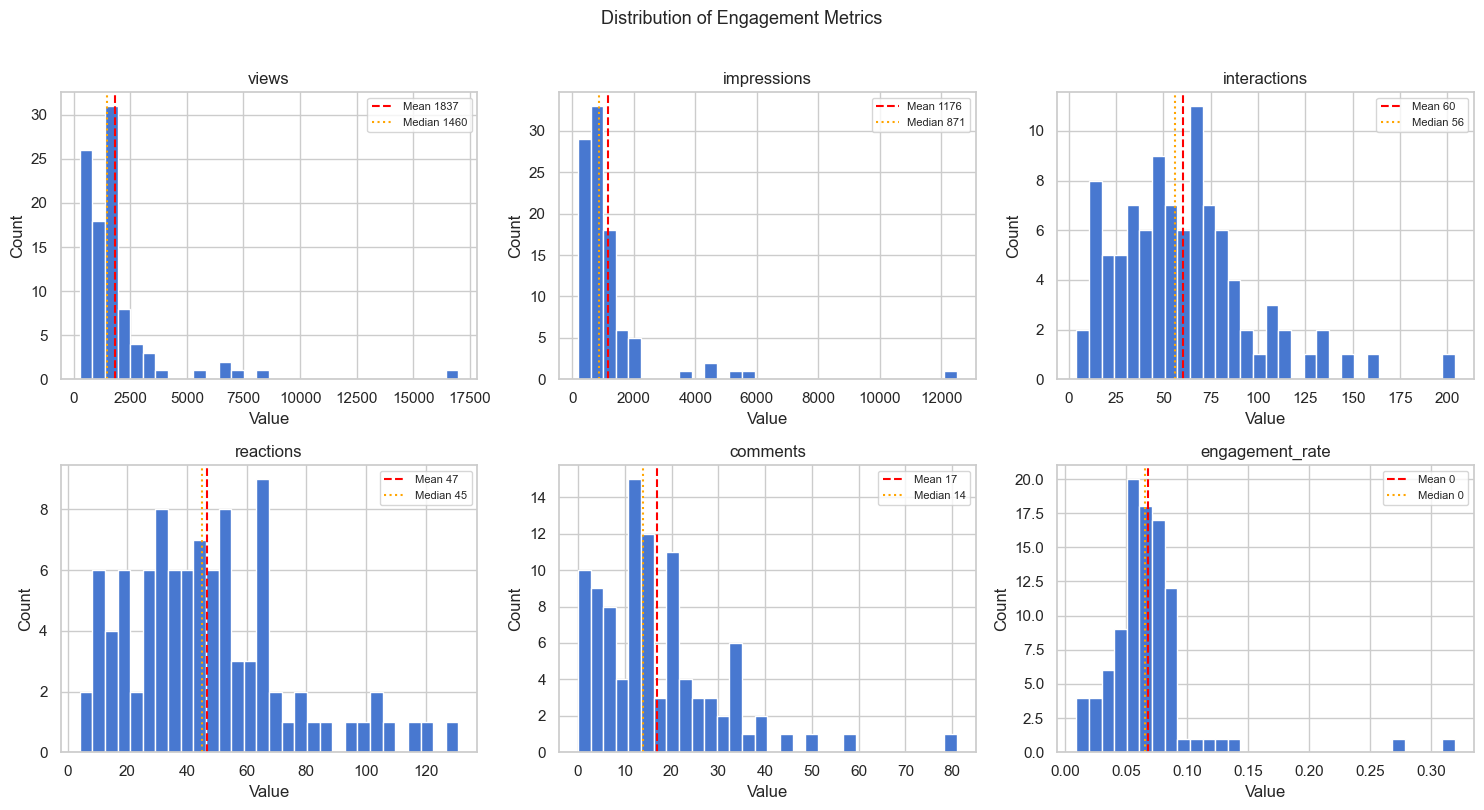

In [32]:
dist_metrics = ["views", "impressions", "interactions",
                "reactions", "comments", "engagement_rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, dist_metrics):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=sns.color_palette("muted")[0], edgecolor="white")
    ax.axvline(data.mean(),   color="red",    linestyle="--", label=f"Mean {data.mean():.0f}")
    ax.axvline(data.median(), color="orange", linestyle=":",  label=f"Median {data.median():.0f}")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Engagement Metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Algorithmic Reach vs Audience Engagement

This scatter plot places every post in a 2D space defined by two independent
dimensions of success:

- **X axis (impressions):** how widely Facebook distributed the post — algorithmic reach
- **Y axis (engagement rate):** how much the audience who saw it actually responded

The dashed lines mark the dataset means, creating four quadrants that match the
post categories: Viral, Algorithm Pushed, Audience Favorite, Low Performance.
Dot size represents total interactions.

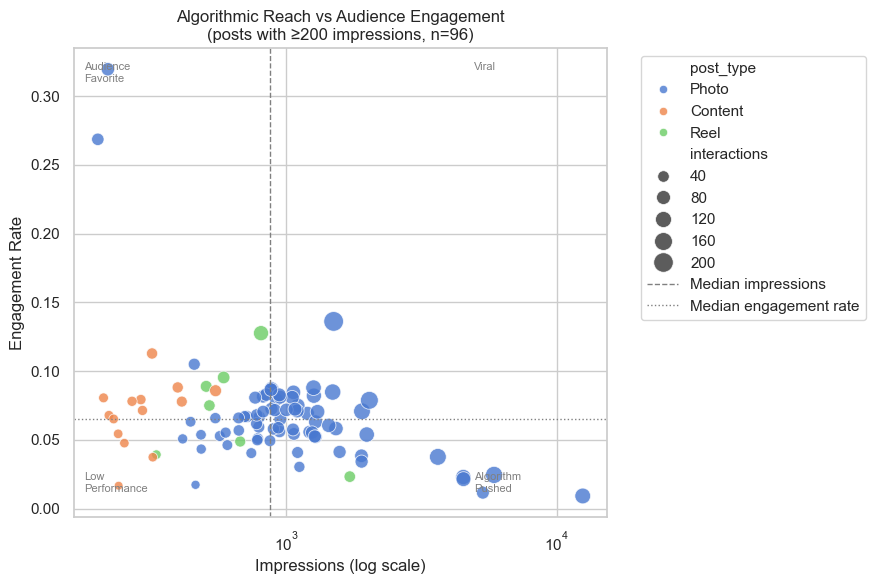

Excluded 1 posts with <200 impressions
Excluded 1 posts with <200 impressions (cover photos / anomalies)


In [33]:
plot_df = df[df["impressions"] >= 200].copy()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_df,
    x="impressions",
    y="engagement_rate",
    hue="post_type",
    size="interactions",
    sizes=(40, 200),
    alpha=0.8,
    palette="muted",
)

plt.xscale("log")
plt.axvline(plot_df["impressions"].median(),     color="grey", linestyle="--", linewidth=1, label="Median impressions")
plt.axhline(plot_df["engagement_rate"].median(), color="grey", linestyle=":",  linewidth=1, label="Median engagement rate")

# Quadrant labels
ax = plt.gca()
ax.text(0.02, 0.97, "Audience\nFavorite",  transform=ax.transAxes, va="top",    fontsize=8, color="grey")
ax.text(0.75, 0.97, "Viral",               transform=ax.transAxes, va="top",    fontsize=8, color="grey")
ax.text(0.02, 0.05, "Low\nPerformance",    transform=ax.transAxes, va="bottom", fontsize=8, color="grey")
ax.text(0.75, 0.05, "Algorithm\nPushed",   transform=ax.transAxes, va="bottom", fontsize=8, color="grey")

plt.xlabel("Impressions (log scale)")
plt.ylabel("Engagement Rate")
plt.title(f"Algorithmic Reach vs Audience Engagement\n(posts with ≥200 impressions, n={len(plot_df)})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Excluded {len(df) - len(plot_df)} posts with <200 impressions")

print(f"Excluded {len(df) - len(plot_df)} posts with <200 impressions (cover photos / anomalies)")

### 3.3 Metric Correlations

A correlation matrix shows how strongly each metric moves together with the others.

This helps identify which metrics are redundant (measuring the same thing)
and which capture genuinely different aspects of performance.

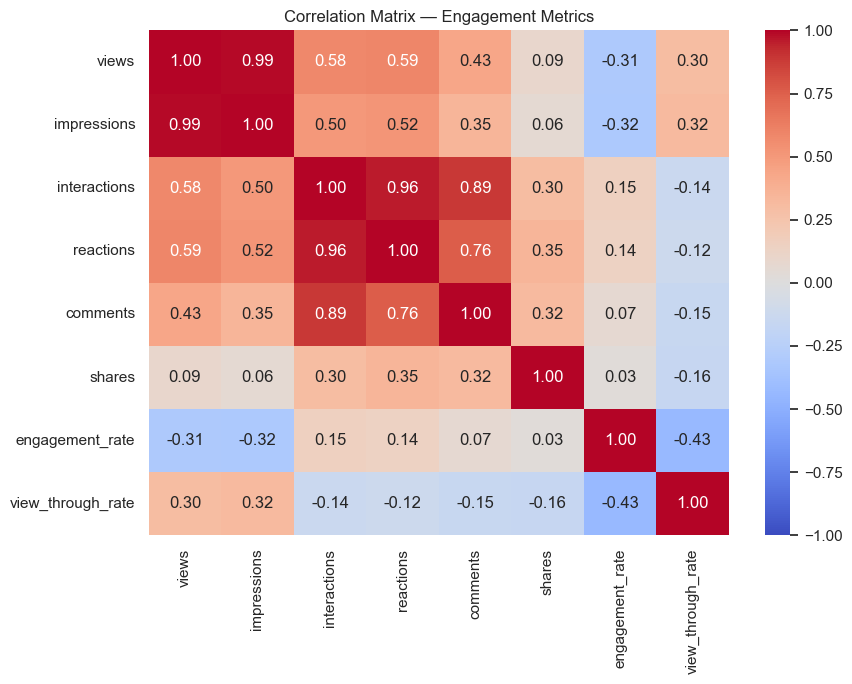

In [34]:
corr_cols = ["views", "impressions", "interactions",
             "reactions", "comments", "shares",
             "engagement_rate", "view_through_rate"]

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix — Engagement Metrics")
plt.tight_layout()
plt.show()

## 4. Post Type Analysis

Does post type systematically affect performance? Photos get image-based algorithmic
distribution, while text-only Content posts rely more on organic reach from followers.
Reels have their own video-specific distribution logic.

### 4.1 Engagement by Post Type

Average engagement metrics per post type. We look at both raw totals
(interactions, impressions) and the rate metric (engagement rate) since they
can tell different stories — a type might get high reach but low resonance, or vice versa.

Average metrics by post type:


,impressions,interactions,engagement_rate,views
post_type,,,,
Content,295.13,21.07,0.07,466.47
Photo,1393.85,69.27,0.07,2200.76
Reel,735.14,47.00,0.07,873.00


/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/1770201350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax,
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/1770201350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax,
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/1770201350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax,


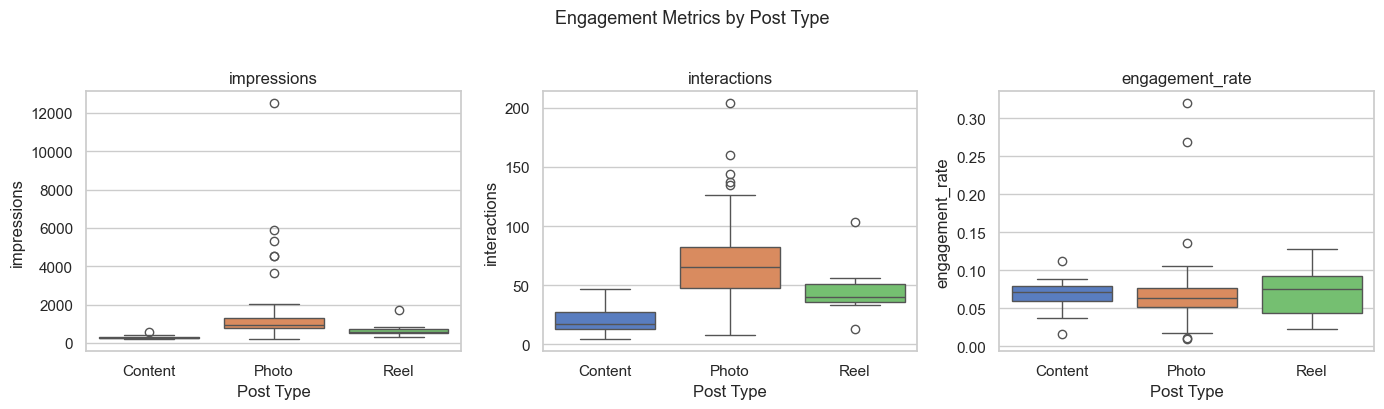

In [35]:
type_perf = (
    df.groupby("post_type")[["impressions", "interactions", "engagement_rate", "views"]]
    .mean()
    .round(2)
    .sort_values("engagement_rate", ascending=False)
)
print("Average metrics by post type:")
display(type_perf)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["impressions", "interactions", "engagement_rate"]):
    sns.boxplot(data=df, x="post_type", y=col, ax=ax,
                palette="muted", order=type_perf.index)
    ax.set_title(col)
    ax.set_xlabel("Post Type")

plt.suptitle("Engagement Metrics by Post Type", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Views and View Rates by Post Type

Beyond engagement, we look at how people *view* posts:
- **repeat_view_rate:** people returning to look again (signals strong interest)
- **view_through_rate:** of everyone who saw it in their feed, how many actually stopped to view it

/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/3308266568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax, palette="muted")
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/3308266568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax, palette="muted")
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_62428/3308266568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="post_type", y=col, ax=ax, palette="muted"

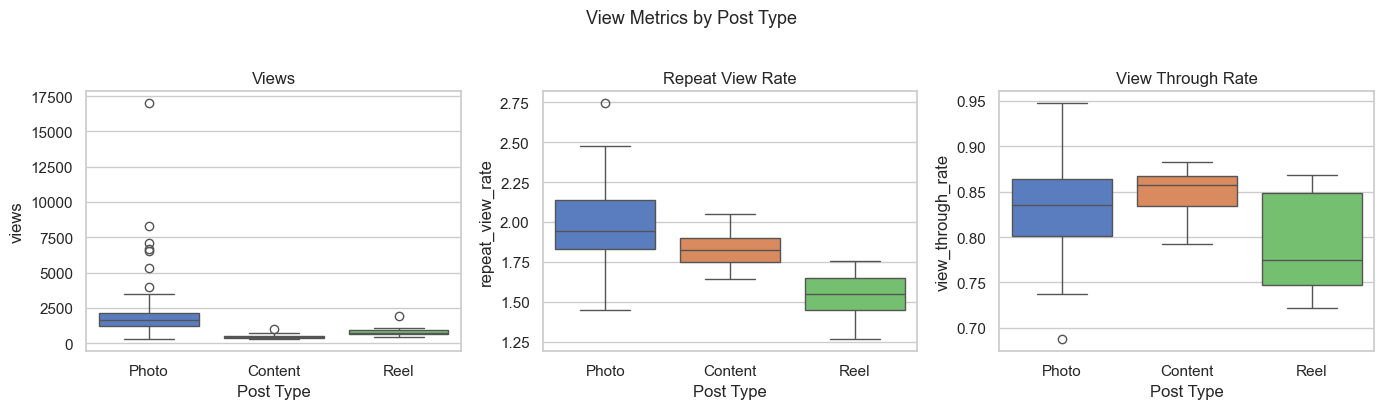

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["views", "repeat_view_rate", "view_through_rate"]):
    sns.boxplot(data=df, x="post_type", y=col, ax=ax, palette="muted")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Post Type")

plt.suptitle("View Metrics by Post Type", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Post Category Breakdown by Type

How do the four performance categories (Viral, Algorithm Pushed, Audience Favorite,
Low Performance) distribute across post types? This reveals whether certain post
types tend to succeed in a particular way — e.g. are Content posts more likely
to be Audience Favorites rather than Viral?

In [37]:
category_order = ["Viral", "Algorithm Pushed", "Audience Favorite", "Low Performance"]

crosstab = pd.crosstab(df["post_category"], df["post_type"])
print("Post category × post type (counts):")
display(crosstab)

# Percentage within each post type
crosstab_pct = pd.crosstab(df["post_category"], df["post_type"], normalize="columns").round(3) * 100
print("\nPost category × post type (% within type):")
display(crosstab_pct)

Post category × post type (counts):


post_type,Content,Photo,Reel
post_category,,,
Algorithm Pushed,0,26,1
Audience Favorite,10,13,4
Low Performance,5,14,2
Viral,0,22,0



Post category × post type (% within type):


post_type,Content,Photo,Reel
post_category,,,
Algorithm Pushed,0.0,34.7,14.3
Audience Favorite,66.7,17.3,57.1
Low Performance,33.3,18.7,28.6
Viral,0.0,29.3,0.0


## 5. Timing Analysis

Does *when* you post affect how it performs? We look at hour of day and day of week
separately, then together. Note that sample sizes per slot are small, so patterns
here are directional rather than definitive.

### 5.1 Hour of Day

Average performance metrics by hour of posting.
Separating engagement rate from impressions is important here — the best hour
for reach may not be the best hour for resonance.

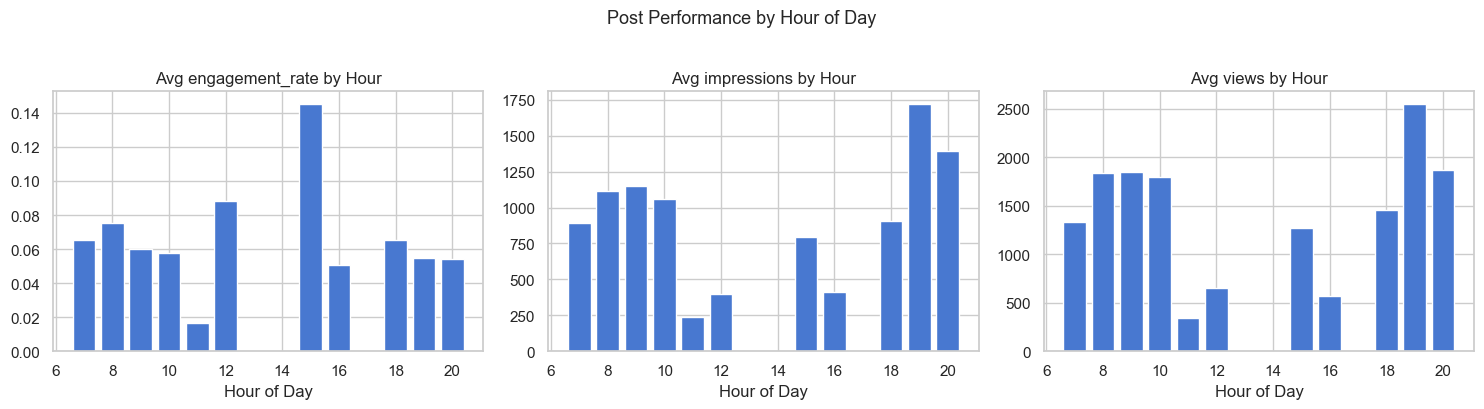


Post count per hour (sample sizes):
{7: 17, 8: 37, 9: 10, 10: 1, 11: 1, 12: 1, 15: 3, 16: 1, 18: 3, 19: 21, 20: 2}


In [38]:
hourly = df.groupby("hour")[["engagement_rate", "impressions", "interactions", "views"]].mean()
hourly_count = df.groupby("hour").size().rename("post_count")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["engagement_rate", "impressions", "views"]):
    ax.bar(hourly.index, hourly[col],
           color=sns.color_palette("muted")[0])
    ax.set_title(f"Avg {col} by Hour")
    ax.set_xlabel("Hour of Day")

plt.suptitle("Post Performance by Hour of Day", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nPost count per hour (sample sizes):")
print(hourly_count.to_dict())

In [ ]:
# Find the post(s) published at 15:00
posts_at_15 = df[df["hour"] == 15][["title", "date", "post_type", "post_category", 
                                     "engagement_rate", "impressions", "interactions"]]
display(posts_at_15.sort_values("engagement_rate", ascending=False))

,title,date,post_type,post_category,engagement_rate,impressions,interactions
96,למה שינויים כל כך מפחידים אותנו? אולי כי הם תמ...,2025-06-04,Photo,Audience Favorite,0.268657,201.0,54.0
44,"זאת הייתה שנה מיוחדת ומורכבת, השנה השלושים ושש...",2025-12-12,Photo,Viral,0.087956,1262.0,111.0
37,הכי כיף זה לפגוש את הקוראים פנים אל פנים!\n\nמ...,2025-12-26,Photo,Viral,0.079434,919.0,73.0


### 5.2 Day of Week

Average performance by day of week, ordered Sunday–Saturday
(Israeli week starts Sunday).

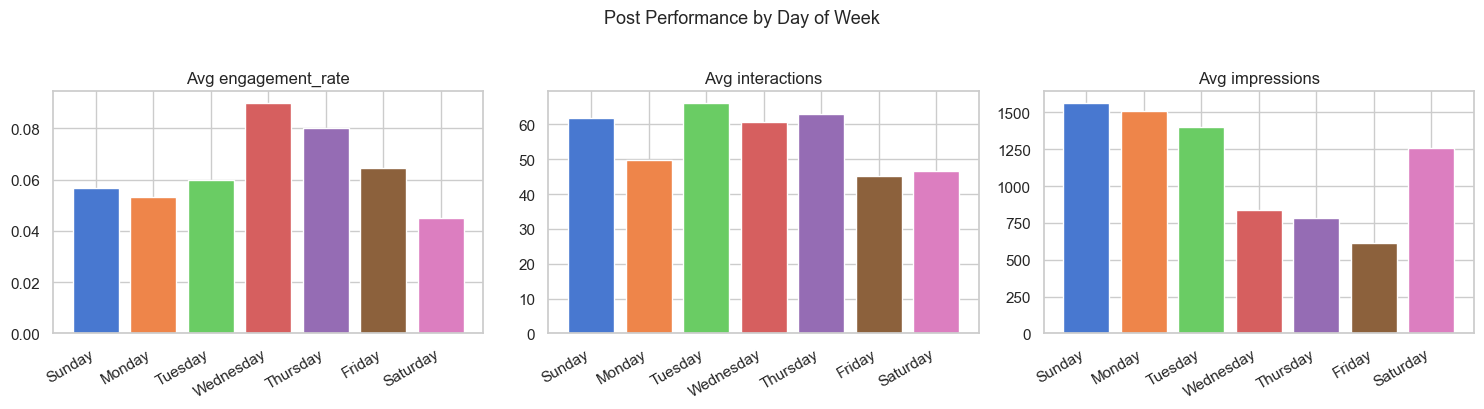


Post count per day (sample sizes):
{'Sunday': 21, 'Monday': 10, 'Tuesday': 22, 'Wednesday': 19, 'Thursday': 17, 'Friday': 6, 'Saturday': 2}


In [40]:
weekday_perf = (
    df.groupby("weekday")[["engagement_rate", "interactions", "impressions"]]
    .mean()
    .reindex(WEEKDAY_ORDER)
    .dropna()
)
weekday_count = df.groupby("weekday").size().reindex(WEEKDAY_ORDER).dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["engagement_rate", "interactions", "impressions"]):
    ax.bar(range(len(weekday_perf)), weekday_perf[col],
           color=sns.color_palette("muted", len(weekday_perf)))
    ax.set_xticks(range(len(weekday_perf)))
    ax.set_xticklabels(weekday_perf.index, rotation=30, ha="right")
    ax.set_title(f"Avg {col}")

plt.suptitle("Post Performance by Day of Week", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nPost count per day (sample sizes):")
print(weekday_count.to_dict())

### 5.3 Combined: Hour, Day, and Post Type

A grid view that shows how all three timing and type variables interact across
five key metrics simultaneously. Each row is a variable, each column a metric.

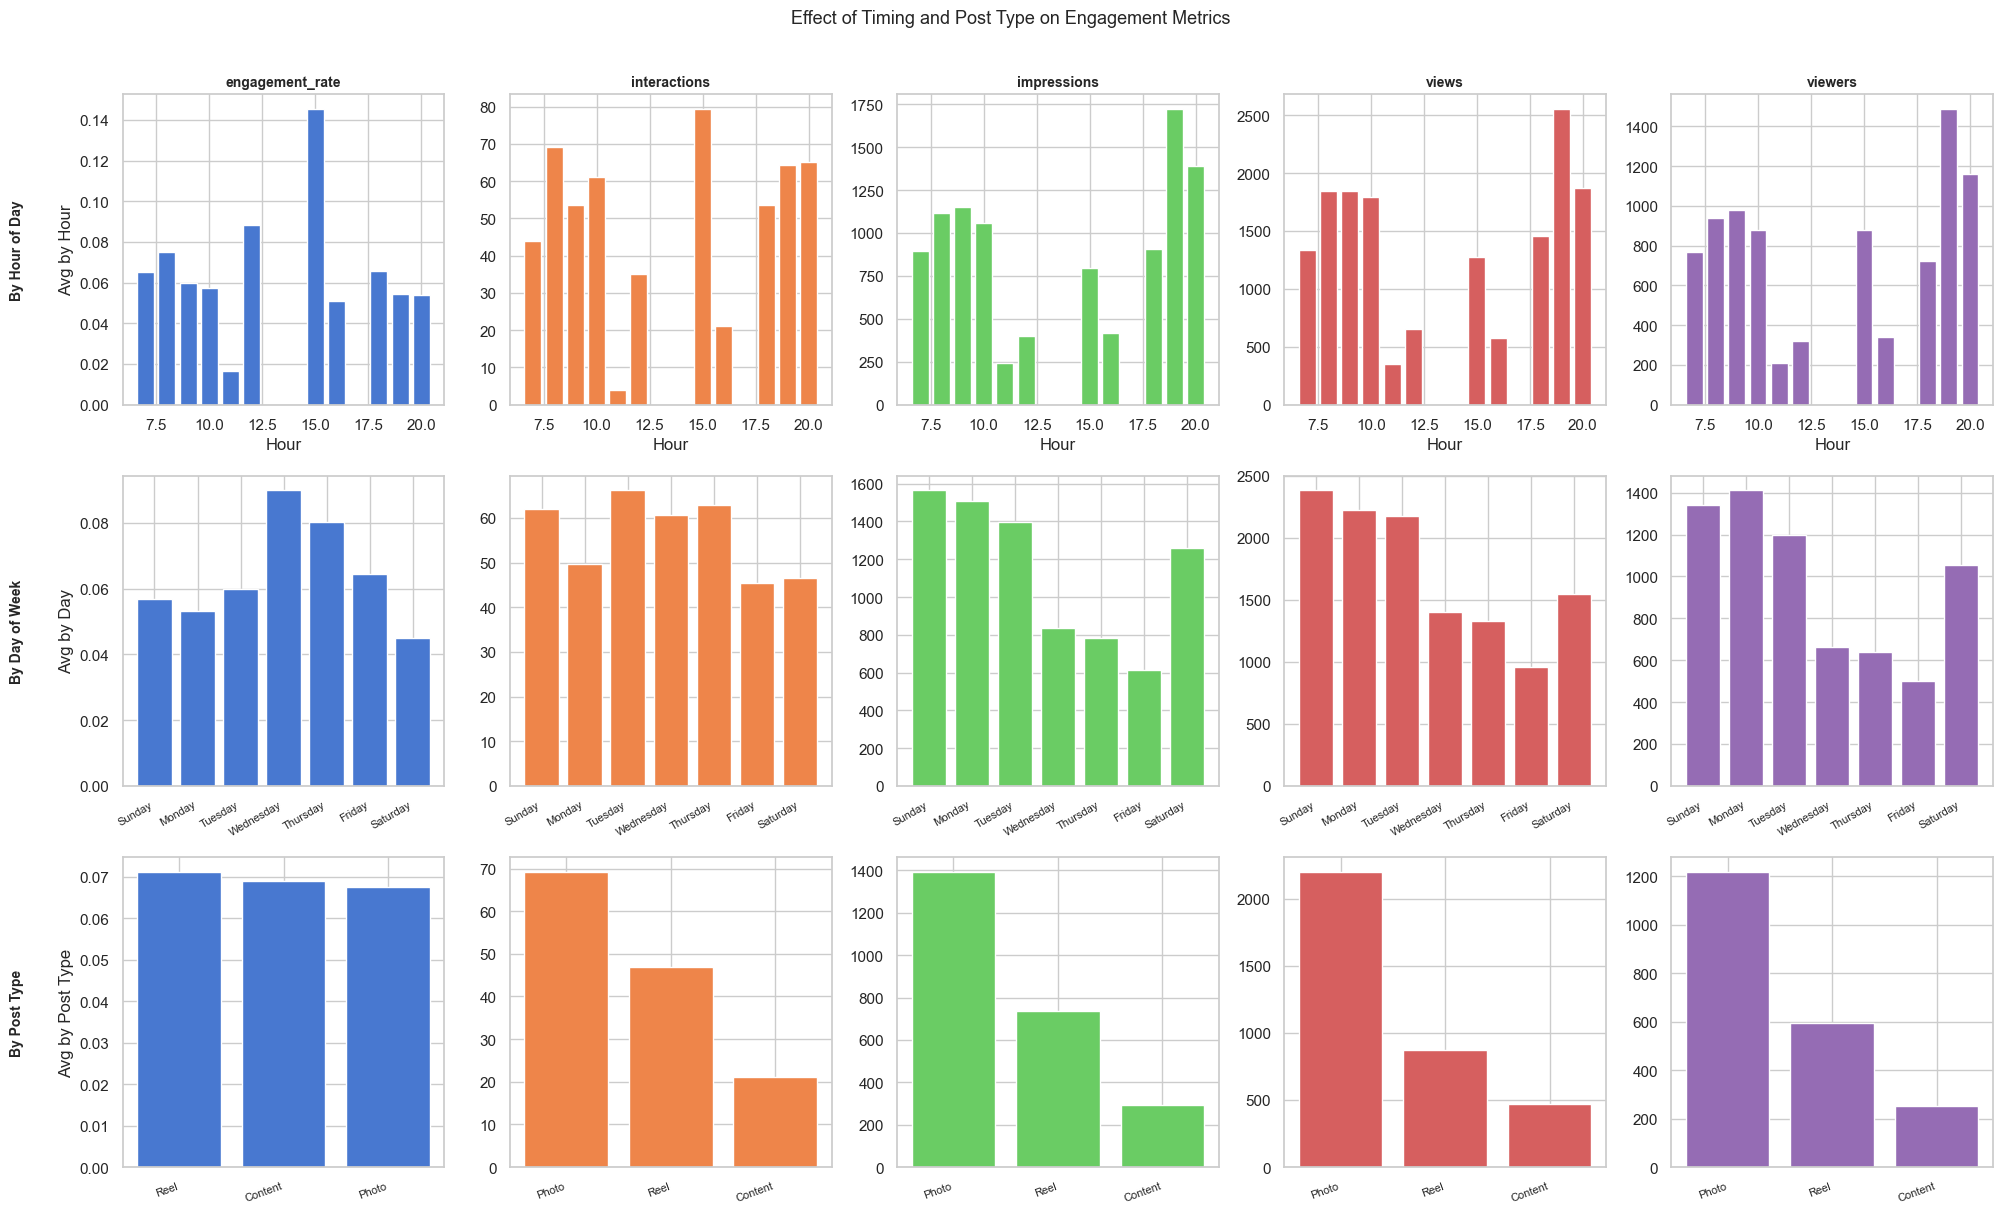

In [41]:
metrics  = ["engagement_rate", "interactions", "impressions", "views", "viewers"]

fig, axes = plt.subplots(3, len(metrics), figsize=(20, 12))

for col_idx, metric in enumerate(metrics):

    # Row 0: by hour of day
    hourly = df.groupby("hour")[metric].mean()
    ax = axes[0, col_idx]
    ax.bar(hourly.index, hourly.values,
           color=sns.color_palette("muted")[col_idx])
    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.set_xlabel("Hour")
    if col_idx == 0: ax.set_ylabel("Avg by Hour")

    # Row 1: by day of week
    daily = df.groupby("weekday")[metric].mean().reindex(WEEKDAY_ORDER).dropna()
    ax = axes[1, col_idx]
    ax.bar(range(len(daily)), daily.values,
           color=sns.color_palette("muted")[col_idx])
    ax.set_xticks(range(len(daily)))
    ax.set_xticklabels(daily.index, rotation=30, ha="right", fontsize=8)
    if col_idx == 0: ax.set_ylabel("Avg by Day")

    # Row 2: by post type
    by_type = df.groupby("post_type")[metric].mean().sort_values(ascending=False)
    ax = axes[2, col_idx]
    ax.bar(range(len(by_type)), by_type.values,
           color=sns.color_palette("muted")[col_idx])
    ax.set_xticks(range(len(by_type)))
    ax.set_xticklabels(by_type.index, rotation=20, ha="right", fontsize=8)
    if col_idx == 0: ax.set_ylabel("Avg by Post Type")

row_labels = ["By Hour of Day", "By Day of Week", "By Post Type"]
for row_idx, label in enumerate(row_labels):
    axes[row_idx, 0].annotate(
        label, xy=(-0.35, 0.5), xycoords="axes fraction",
        fontsize=10, fontweight="bold", rotation=90, va="center"
    )

plt.suptitle("Effect of Timing and Post Type on Engagement Metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Text Length Analysis

Does writing more — or less — affect how a post performs?
We look at the relationship between text length (in words) and the key
engagement metrics. We check both raw correlation and a visual scatter to
see if the relationship is linear or more complex.

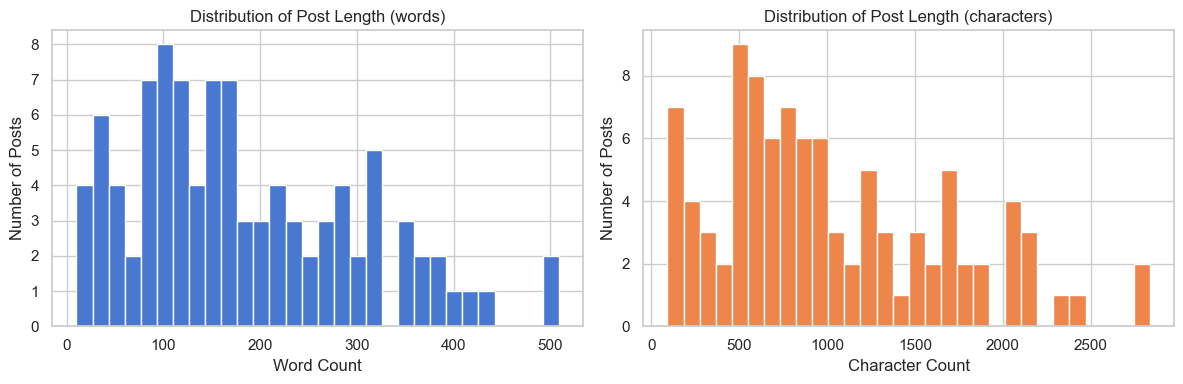

In [42]:
# Distribution of post length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["text_length_words"].dropna(), bins=30,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_title("Distribution of Post Length (words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Posts")

axes[1].hist(df["text_length_chars"].dropna(), bins=30,
             color=sns.color_palette("muted")[1], edgecolor="white")
axes[1].set_title("Distribution of Post Length (characters)")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [43]:
# Correlation between text length and engagement metrics
length_corr = df[["text_length_words", "text_length_chars",
                   "engagement_rate", "impressions", "interactions", "views"]].corr()

print("Correlations with text length:")
display(
    length_corr[["text_length_words", "text_length_chars"]]
    .drop(["text_length_words", "text_length_chars"])
    .round(3)
)

Correlations with text length:


,text_length_words,text_length_chars
engagement_rate,0.035,0.024
impressions,0.106,0.107
interactions,0.275,0.261
views,0.145,0.144


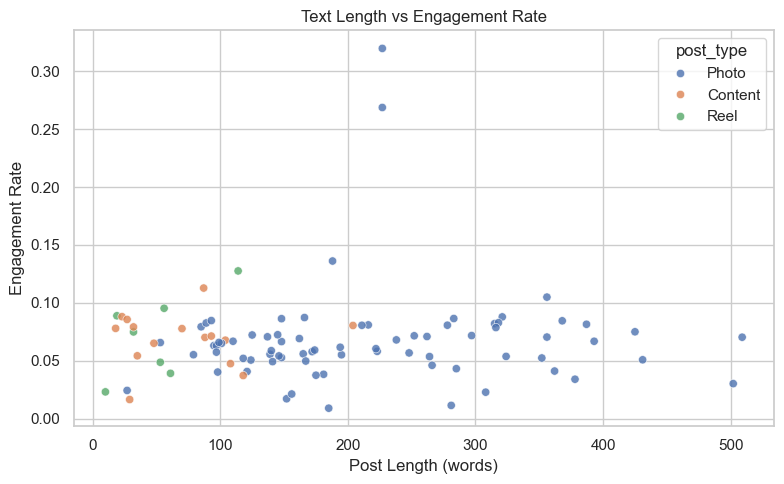

In [44]:
# Scatter: word count vs engagement rate, coloured by post type
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="text_length_words",
    y="engagement_rate",
    hue="post_type",
    alpha=0.8
)
plt.xlabel("Post Length (words)")
plt.ylabel("Engagement Rate")
plt.title("Text Length vs Engagement Rate")
plt.tight_layout()
plt.show()

## 7. OLS Regression: What Predicts Performance?

We run two simple OLS regressions to quantify the effect of timing and post type
on performance — moving from 'what does the chart suggest' to 'is this statistically
meaningful'.

**Two models:**
1. Dependent variable: `log(views + 1)` — log-transformed to correct for right skew
2. Dependent variable: `engagement_rate`

**Independent variables:**
- `hour` — numeric
- `weekday` — dummy-encoded (Sunday as reference)
- `post_type` — dummy-encoded (Content as reference)

Coefficients are interpreted relative to the reference category.
A significant positive coefficient on `type_Photo` means Photo posts perform
better than Content posts on average, holding hour and day constant.

**Important caveat:** with ~99 posts, these results are directional, not definitive.
Adding more data will increase statistical power.

In [45]:
reg_df = df[["hour", "weekday", "post_type", "views", "engagement_rate"]].dropna().copy()
reg_df["log_views"] = np.log1p(reg_df["views"])

weekday_dummies   = pd.get_dummies(reg_df["weekday"],   prefix="day",  drop_first=False).drop(columns=["day_Sunday"]).astype(int)
post_type_dummies = pd.get_dummies(reg_df["post_type"], prefix="type", drop_first=False).drop(columns=["type_Content"]).astype(int)

X = pd.concat([reg_df[["hour"]], weekday_dummies, post_type_dummies], axis=1).astype(float)
X = sm.add_constant(X)

print(f"Sample size: {len(reg_df)}")
print(f"Features: {list(X.columns)}")

Sample size: 97
Features: ['const', 'hour', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'type_Photo', 'type_Reel']


In [46]:
print("=" * 60)
print("Model 1: OLS on log(views + 1)")
print("=" * 60)
model1 = sm.OLS(reg_df["log_views"], X).fit()
print(model1.summary())

Model 1: OLS on log(views + 1)
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     8.708
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.28e-09
Time:                        10:59:39   Log-Likelihood:                -83.052
No. Observations:                  97   AIC:                             186.1
Df Residuals:                      87   BIC:                             211.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          

In [47]:
print("=" * 60)
print("Model 2: OLS on engagement_rate")
print("=" * 60)
model2 = sm.OLS(reg_df["engagement_rate"], X).fit()
print(model2.summary())

Model 2: OLS on engagement_rate
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1.469
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.172
Time:                        10:59:39   Log-Likelihood:                 181.32
No. Observations:                  97   AIC:                            -342.6
Df Residuals:                      87   BIC:                            -316.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         

## 8. Key Findings

A summary of the main patterns observed. Update this cell as new data is added
or as analysis deepens — treat it as a living document, not a fixed conclusion.

In [48]:
# Dynamic findings summary — recalculates with new data
top_type_eng   = df.groupby("post_type")["engagement_rate"].mean().idxmax()
top_type_reach = df.groupby("post_type")["impressions"].mean().idxmax()
top_hour_eng   = df.groupby("hour")["engagement_rate"].mean().idxmax()
top_day_eng    = df.groupby("weekday")["engagement_rate"].mean().idxmax()
viral_pct      = (df["post_category"] == "Viral").mean()
low_pct        = (df["post_category"] == "Low Performance").mean()
length_corr_val = df[["text_length_words", "engagement_rate"]].corr().iloc[0, 1]

print("=" * 60)
print("  KEY FINDINGS")
print("=" * 60)
print(f"  Best post type for engagement:  {top_type_eng}")
print(f"  Best post type for reach:       {top_type_reach}")
print(f"  Best hour for engagement rate:  {top_hour_eng}:00")
print(f"  Best day for engagement rate:   {top_day_eng}")
print(f"  Viral posts:                    {viral_pct:.0%} of total")
print(f"  Low performance posts:          {low_pct:.0%} of total")
print(f"  Text length vs engagement corr: {length_corr_val:.3f}")
print("=" * 60)
print()
print("Note: timing results are based on small per-slot sample sizes.")
print("Patterns will stabilize as more posts are added.")

  KEY FINDINGS
  Best post type for engagement:  Reel
  Best post type for reach:       Photo
  Best hour for engagement rate:  15:00
  Best day for engagement rate:   Wednesday
  Viral posts:                    23% of total
  Low performance posts:          22% of total
  Text length vs engagement corr: 0.035

Note: timing results are based on small per-slot sample sizes.
Patterns will stabilize as more posts are added.
